<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/Training_bert-base-romanian-cased-v1_on_xquad-ro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What if my dataset isn't on the Hub?

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]

In [2]:
!pip install transformers

In [63]:
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-test.json.gz

--2026-07-02 18:42:32--  https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz [following]
--2026-07-02 18:42:33--  https://raw.githubusercontent.com/crux82/squad-it/master/SQuAD_it-train.json.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7725286 (7.4M) [application/octet-stream]
Saving to: ‘SQuAD_it-train.json.gz’

SQuAD_it-train.json 100%[===================>]   7.37M  --.-KB/s    in 0.06s   

2026-07-02 18:42:33 (122 MB/s) - ‘SQuAD_it-train.json.gz’ saved [7725286/7725286]

--2026

In [3]:
!wget -O xquad.ro.json https://raw.githubusercontent.com/google-deepmind/xquad/master/xquad.ro.json

--2026-07-02 18:54:25--  https://raw.githubusercontent.com/google-deepmind/xquad/master/xquad.ro.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 661158 (646K) [text/plain]
Saving to: ‘xquad.ro.json’

xquad.ro.json       100%[===================>] 645.66K  --.-KB/s    in 0.03s   

2026-07-02 18:54:25 (20.5 MB/s) - ‘xquad.ro.json’ saved [661158/661158]



In [4]:
from datasets import load_dataset

xquad_ro_dataset = load_dataset("json", data_files="xquad.ro.json", split='train')

Generating train split: 0 examples [00:00, ? examples/s]

In [50]:
xquad_ro_dataset

Dataset({
    features: ['data', 'version'],
    num_rows: 48
})

In [21]:
xquad_ro_dataset['train'][0]

{'data': {'paragraphs': [{'context': 'Apărarea Panthers a cedat doar 308 puncte, clasându-se pe locul șase din ligă, în timp ce au dominat NFL la interceptări, în număr de 24 și s-au putut lăuda cu patru selecții la Pro Bowl. Jucătorul principal al apărării la Pro Bowl, Kawann Short, a condus echipa la numărul de sack-uri cu 11, forțând și trei fumble-uri și recuperând două. Coechipierul de linie Mario Addison a adăugat încă 6½ sack-uri. Din linia Panthers a făcut parte și veteranul apărător din extremă Jared Allen, care a participat de 5 ori la Pro Bowl, fiind liderul activ al NFL la numărul de sack-uri de-a lungul carierei, în număr de 136, alături de apărătorul din extremă Kony Ealy, care a avut 5 sack-uri în doar 9 meciuri pe poziție de starter. În spatele lor, au fost selectați și doi dintre cei trei jucători din spatele liniei defensive ai Panthers pentru a juca la Pro Bowl: Thomas Davis și Luke Kuechly. Davis a adunat 5½ sack-uri, patru fumble-uri forțate, și patru interceptări,

In [8]:
from datasets import load_dataset

split_dataset = xquad_ro_dataset.train_test_split(test_size=0.2, seed=42)

In [31]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'version'],
        num_rows: 38
    })
    test: Dataset({
        features: ['data', 'version'],
        num_rows: 10
    })
})

In [9]:
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

checkpoint = "dumitrescustefan/bert-base-romanian-cased-v1"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def flatten_squad_split(split_data):
    flat_rows = []
    for item in split_data['data']:
        for paragraph in item['paragraphs']:
            context = paragraph['context']
            for qa in paragraph['qas']:
                question = qa['question']

                if 'answers' in qa and len(qa['answers']) > 0:
                    ans_list = qa['answers']
                    ans = ans_list[0] if isinstance(ans_list, list) else ans_list
                    start_char = ans['answer_start']
                    end_char = start_char + len(ans['text'])
                else:
                    start_char, end_char = 0, 0

                flat_rows.append({
                    "question": question,
                    "context": context,
                    "start_char": start_char,
                    "end_char": end_char
                })
    return flat_rows

train_flat = flatten_squad_split(split_dataset['train'])
new_train_dataset = Dataset.from_list(train_flat)

def tokenize_flat_function(examples):
    tokenized_inputs = tokenizer(
        examples["question"],
        examples["context"],
        truncation=True,
        padding="max_length",
        max_length=384,
        return_offsets_mapping=True
    )

    final_start_positions = []
    final_end_positions = []
    max_len = 384

    for i in range(len(examples["question"])):
        start_tok = tokenized_inputs.char_to_token(i, examples["start_char"][i], sequence_index=1)
        end_tok = tokenized_inputs.char_to_token(i, examples["end_char"][i] - 1, sequence_index=1)

        if start_tok is None or start_tok >= max_len:
            start_tok = 0
        if end_tok is None or end_tok >= max_len:
            end_tok = 0
        if start_tok > end_tok:
            start_tok, end_tok = 0, 0

        final_start_positions.append(start_tok)
        final_end_positions.append(end_tok)

    tokenized_inputs.pop("offset_mapping")
    tokenized_inputs["start_positions"] = final_start_positions
    tokenized_inputs["end_positions"] = final_end_positions

    return tokenized_inputs


tokenized_train = new_train_dataset.map(
    tokenize_flat_function,
    batched=True,
    remove_columns=new_train_dataset.column_names
)

tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "start_positions", "end_positions"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    tokenized_train,
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator
)


Map:   0%|          | 0/955 [00:00<?, ? examples/s]

In [11]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'version'],
        num_rows: 38
    })
    test: Dataset({
        features: ['data', 'version'],
        num_rows: 10
    })
})

In [12]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

for batch in train_dataloader:
  break
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([8, 384]),
 'token_type_ids': torch.Size([8, 384]),
 'attention_mask': torch.Size([8, 384]),
 'start_positions': torch.Size([8]),
 'end_positions': torch.Size([8])}

In [13]:
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(checkpoint, num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: dumitrescustefan/bert-base-romanian-cased-v1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

In [14]:
import torch

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
model.to(device)

for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}

    outputs = model(**batch)
    break
outputs.loss

tensor(5.8831, device='cuda:0', grad_fn=<DivBackward0>)

In [15]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)


In [16]:
from transformers import get_scheduler

num_epochs=5
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)
num_training_steps

600

In [17]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))
loss_list = []
model.train()
for epoch in range(num_epochs):
  total_loss = 0
  for batch in train_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    optimizer.zero_grad()

    outputs = model(**batch)
    loss = outputs.loss

    loss.backward()
    optimizer.step()
    lr_scheduler.step()

    total_loss += loss.item()

    progress_bar.update(1)

    loss_list.append(loss.item())

  print(f"Mean loss: {total_loss / len(train_dataloader):.4f}")

  0%|          | 0/600 [00:00<?, ?it/s]

Mean loss: 3.4958
Mean loss: 1.6099
Mean loss: 0.5840
Mean loss: 0.2337
Mean loss: 0.1199


In [18]:
!pip install matplotlib

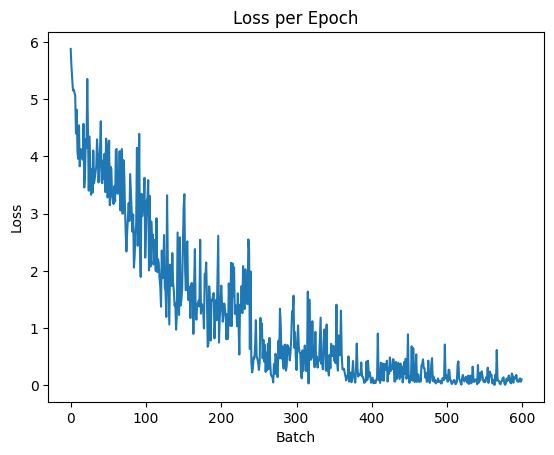

In [19]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.show()

In [20]:
!pip install evaluate

In [22]:
import evaluate
import torch
from datasets import Dataset
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

metric = evaluate.load('squad')

val_split_name = 'validation' if 'validation' in split_dataset else 'test'
val_flat = flatten_squad_split(split_dataset[val_split_name])
new_val_dataset = Dataset.from_list(val_flat)

tokenized_val = new_val_dataset.map(tokenize_flat_function, batched=True, remove_columns=new_val_dataset.column_names)
tokenized_val.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "start_positions", "end_positions"])

test_dataloader = DataLoader(tokenized_val, shuffle=False, batch_size=8, collate_fn=data_collator)

all_preds = []
all_references = []

model.eval()
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    start_preds = torch.argmax(outputs.start_logits, dim=-1).cpu().tolist()
    end_preds = torch.argmax(outputs.end_logits, dim=-1).cpu().tolist()

    for i in range(len(start_preds)):
        pred_text = tokenizer.decode(batch['input_ids'][i][start_preds[i]:end_preds[i]+1], skip_special_tokens=True)
        ref_text = tokenizer.decode(batch['input_ids'][i][batch['start_positions'][i]:batch['end_positions'][i]+1], skip_special_tokens=True)

        all_preds.append({
            'id': str(len(all_preds)),
            'prediction_text': pred_text.strip()
        })

        all_references.append({
            'id': str(len(all_references)),
            'answers': {
                "answer_start": [int(batch['start_positions'][i].cpu())],
                'text': [ref_text.strip()]
            }
        })

results = metric.compute(predictions=all_preds, references=all_references)
print(results)

Map:   0%|          | 0/235 [00:00<?, ? examples/s]

{'exact_match': 32.340425531914896, 'f1': 45.49565016524512}
